In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [165]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [166]:
df = pd.read_csv('diabetes.csv')
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions : 768 lignes × 9 colonnes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [167]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [168]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [169]:
#valeurs manquantes
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [170]:
print(f"\nTotal valeurs manquantes : {df.isnull().sum().sum()}")


Total valeurs manquantes : 0


In [171]:
# Remplacer les 0 impossibles par NaN
cols_suspects = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_suspects] = df[cols_suspects].replace(0, np.nan)

# Remplacer NaN par la moyenne
df[cols_suspects] = df[cols_suspects].fillna(df[cols_suspects].mean())

print("Nettoyage terminé !")

Nettoyage terminé !


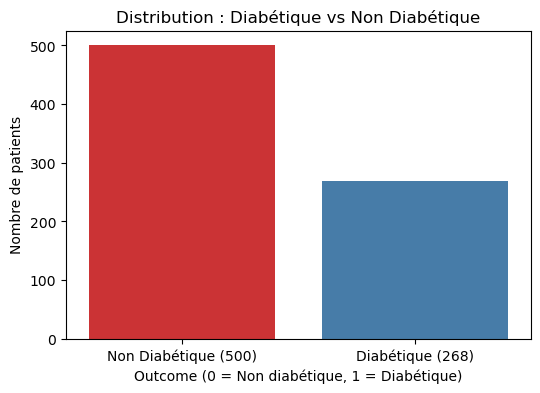

Outcome
0    500
1    268
Name: count, dtype: int64


In [172]:
# Distribution de la variable cible
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, palette='Set1')
plt.title('Distribution : Diabétique vs Non Diabétique')
plt.xlabel('Outcome (0 = Non diabétique, 1 = Diabétique)')
plt.ylabel('Nombre de patients')
plt.xticks([0, 1], ['Non Diabétique (500)', 'Diabétique (268)'])
plt.show()


print(df['Outcome'].value_counts())

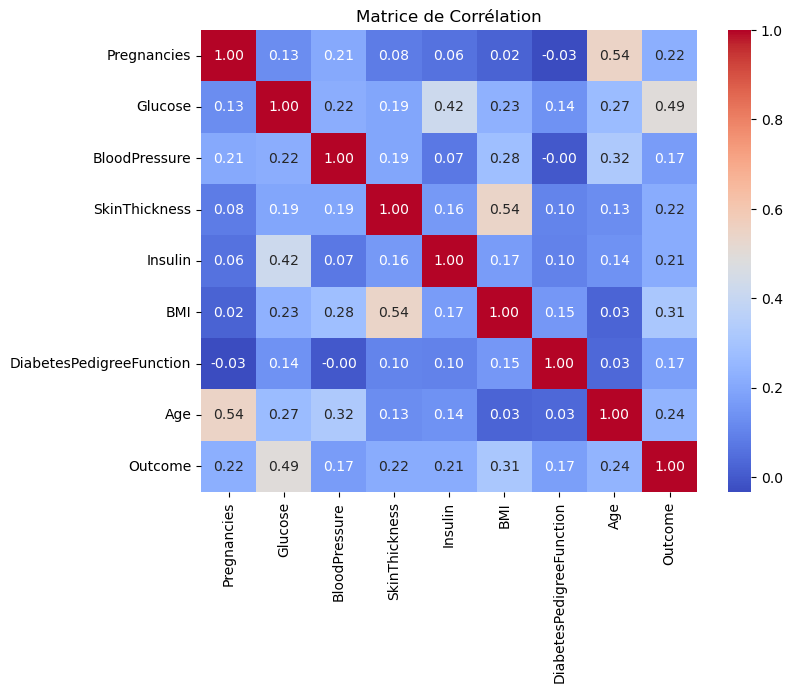

In [173]:
#matrice de Corrélation entre variables
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de Corrélation')
plt.show()

In [174]:
# features
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"Taille de X : {X.shape}")  
print(f"Taille de y : {y.shape}") 

Taille de X : (768, 8)
Taille de y : (768,)


In [175]:
#Train / Test Split (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape[0]} échantillons")
print(f"Test  : {X_test.shape[0]} échantillons")

Train : 614 échantillons
Test  : 154 échantillons


In [176]:
# Validation croisée avec 10 folds
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [177]:
#mod1: Régression Logistique
r = LogisticRegression(random_state=42, class_weight='balanced')
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
cv_lr = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')
print(f"  Régression Logistique : {cv_lr.mean()*100:.2f}")
print(f" Accuracy Régression Logistique : {acc_lr*100:.2f}%")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_lr))

  Régression Logistique : 76.30
 Accuracy Régression Logistique : 76.62%

Rapport de classification :
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        99
           1       0.69      0.62      0.65        55

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



In [178]:
#mod2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
#rf = RandomForestClassifier(n_estimators=128, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
cv_rf = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print(f"  Random Forest         : {cv_rf.mean()*100:.2f}")
print(f"Accuracy Random Forest : {acc_rf*100:.2f}%")
print("\n Rapport de classification :")
print(classification_report(y_test, y_pred_rf))

  Random Forest         : 75.12
Accuracy Random Forest : 75.97%

 Rapport de classification :
              precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



In [179]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=32, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
cv_gb = cross_val_score(gb, X, y, cv=cv, scoring='accuracy')
print(f"  Gradient Boosting     : {cv_gb.mean()*100:.2f}")
print(f"Accuracy Gradient Boosting : {acc_gb*100:.2f}%")
print("\n Rapport de classification :")
print(classification_report(y_test, y_pred_gb))

  Gradient Boosting     : 75.90
Accuracy Gradient Boosting : 77.27%

 Rapport de classification :
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        99
           1       0.69      0.67      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [180]:
# Comparaison des modèles
print("=" * 45)
print("        COMPARAISON DES MODÈLES")
print("=" * 45)
print(f"  Régression Logistique : {acc_lr*100:.2f}%")
print(f"  Random Forest         : {acc_rf*100:.2f}%")
print(f"  Gradient Boosting     : {acc_gb*100:.2f}%")
print("=" * 45)

# Meilleur modèle
scores = {
    "RÉGRESSION LOGISTIQUE": acc_lr,
    "RANDOM FOREST": acc_rf,
    "GRADIENT BOOSTING": acc_gb
}
meilleur = max(scores, key=scores.get)
print(f"Meilleur modèle : {meilleur}")

        COMPARAISON DES MODÈLES
  Régression Logistique : 76.62%
  Random Forest         : 75.97%
  Gradient Boosting     : 77.27%
Meilleur modèle : GRADIENT BOOSTING


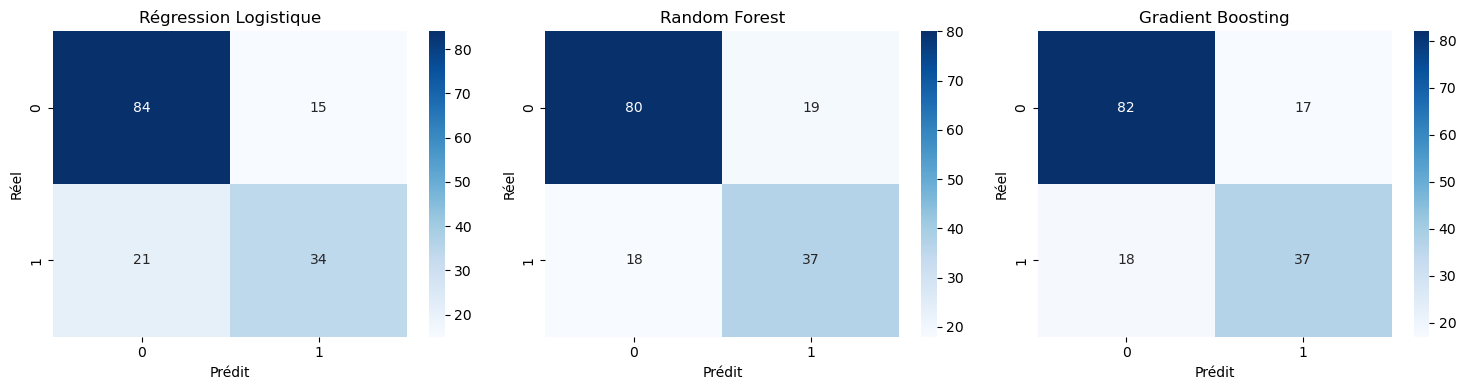

In [181]:
# Confusion Matrix des 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modeles = [
    ("Régression Logistique", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("Gradient Boosting", y_pred_gb)
]

for ax, (nom, y_pred) in zip(axes, modeles):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(nom)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()